# Green Space Exposure Audit

Measure green-space exposure differences across neighborhoods using local polygons and observation points.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Workflow pattern adapted from GeoPandas examples for joins, choropleths, and exploratory mapping.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
zones = gpd.read_file(DATA / 'zones.geojson')
obs = pd.read_csv(DATA / 'observations.csv')
points = gpd.GeoDataFrame(obs, geometry=gpd.points_from_xy(obs.lon, obs.lat), crs='EPSG:4326')
print({'zones': len(zones), 'observations': len(points), 'crs': str(zones.crs)})
display(zones.head())


{'zones': 25, 'observations': 100, 'crs': 'EPSG:4326'}


,zone_id,district,score,population,green_ratio,geometry
0,Z0000,District 1,44.941669,9610,0.135599,"POLYGON ((118.725 31.9, 118.725 31.922, 118.7 ..."
1,Z0001,District 1,46.393187,11560,0.128236,"POLYGON ((118.76 31.9, 118.76 31.922, 118.735 ..."
2,Z0002,District 1,39.161182,6861,0.157741,"POLYGON ((118.795 31.9, 118.795 31.922, 118.77..."
3,Z0003,District 1,29.550186,3601,0.133853,"POLYGON ((118.83 31.9, 118.83 31.922, 118.805 ..."
4,Z0004,District 1,36.576518,4234,0.116490,"POLYGON ((118.865 31.9, 118.865 31.922, 118.84..."


In [2]:
joined = gpd.sjoin(points, zones[['zone_id', 'score', 'geometry']], predicate='within', how='left')
summary = joined.groupby('zone_id').agg(mean_value=('value', 'mean'), observations=('id', 'count')).reset_index()
zones2 = zones.merge(summary, on='zone_id', how='left').fillna({'mean_value': 0, 'observations': 0})
zones2['priority_index'] = (zones2['mean_value'] * 0.65 + zones2['score'] * 0.35).round(2)
display(zones2[['zone_id', 'score', 'mean_value', 'observations', 'priority_index']].sort_values('priority_index', ascending=False).head(8))


,zone_id,score,mean_value,observations,priority_index
6,Z0101,47.698228,80.710000,1.0,69.16
7,Z0102,48.269806,80.143333,3.0,68.99
1,Z0001,46.393187,77.988000,5.0,66.93
11,Z0201,53.750222,69.714000,5.0,64.13
2,Z0002,39.161182,76.405000,2.0,63.37
21,Z0401,54.375369,66.020000,1.0,61.94
0,Z0000,44.941669,67.090000,2.0,59.34
22,Z0402,52.086625,62.833333,3.0,59.07


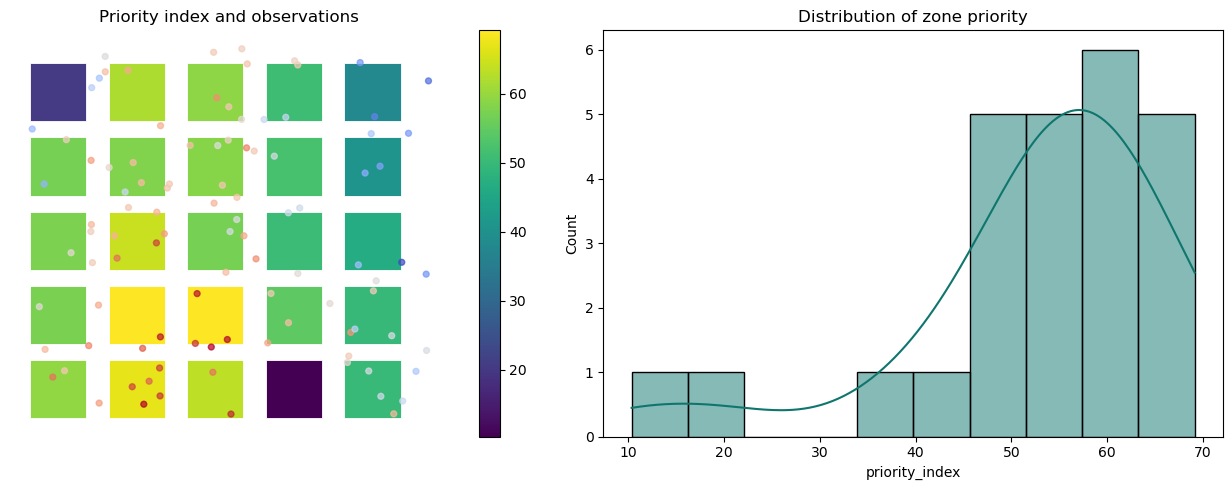

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
zones2.plot(column='priority_index', cmap='viridis', legend=True, ax=axes[0], edgecolor='white', linewidth=0.6)
points.plot(column='value', cmap='coolwarm', markersize=18, alpha=0.72, ax=axes[0])
axes[0].set_title('Priority index and observations')
axes[0].set_axis_off()
sns.histplot(zones2['priority_index'], bins=10, kde=True, ax=axes[1], color='#0f766e')
axes[1].set_title('Distribution of zone priority')
fig.tight_layout()
fig.savefig(OUT / 'priority_map.png', dpi=160)
plt.show()


In [4]:
center = [points.geometry.y.mean(), points.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles='CartoDB positron')
folium.Choropleth(
    geo_data=zones2.to_json(), data=zones2, columns=['zone_id', 'priority_index'], key_on='feature.properties.zone_id',
    fill_color='YlOrRd', fill_opacity=0.62, line_opacity=0.3, legend_name='Priority index'
).add_to(m)
for row in points.sample(min(35, len(points)), random_state=7).itertuples():
    folium.CircleMarker([row.lat, row.lon], radius=3, color='#1d4ed8', fill=True, fill_opacity=0.72, popup=f'{row.id}: {row.value}').add_to(m)
m.save(OUT / 'interactive_map.html')
display(m)


In [5]:
top = zones2.sort_values('priority_index', ascending=False).head(5)
print('Top intervention zones:')
for row in top.itertuples():
    print(f'- {row.zone_id}: priority={row.priority_index}, observations={int(row.observations)}')


Top intervention zones:
- Z0101: priority=69.16, observations=1
- Z0102: priority=68.99, observations=3
- Z0001: priority=66.93, observations=5
- Z0201: priority=64.13, observations=5
- Z0002: priority=63.37, observations=2
